# <center>**INFO-6149 (26W) Machine Learning Security**</center>
## <center>**Project: Attack Detection and Defense**</ceneter>
## <center>**Dataset: German Traffic Sign Recognition Benchmark**</ceneter>
## <center>**Professor: Bestan Maaroof**</center>
## <center>**Group: 05**</center>
### Group Members: 

###   1. Yun-Jiung Wang - 1256222 
###   2. Allyson Fuller - 0763664 
###   3. Gitanshu Gitanshu - 1352882 



### Import Libs

In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay

# SecML related
from secml.array import CArray
from secml.data import CDataset
from secml.ml.classifiers import CClassifierPyTorch
from secml.ml.peval.metrics import CMetricAccuracy

import time

### Check Device (CPU or GPU)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Part 1:  Detecting Data Poisoning and Adversarial Attacks in Machine Learning 
In this part of the project you investigate training-time (data poisoning) and inference-time (adversarial) vulnerabilities in ML models through controlled experiments. You will work on a dataset, build a machine-learning model, test it for vulnerabilities.
### Phase 1: Dataset Selection and Preprocessing 
1. Select a suitable dataset for your project. It could be a standard dataset like MNIST, CIFAR-10, or one relevant to your domain.
2. Implement preprocessing pipeline: Normalization, train-test splits (70-30) 


#### Load the dataset

In [3]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

full_train_ds = datasets.GTSRB(
    root="./data",
    split="train",
    transform=transform,
    download=True
)

full_test_ds = datasets.GTSRB(
    root="./data",
    split="test",
    transform=transform,
    download=True
)

#### Data Pre-Processing

In [4]:
# Stratified Split
def get_data(dataset, n_samples):
    labels = [s[1] for s in dataset._samples]
    indices = np.arange(len(dataset))
    # make sure every label could be trained
    idx, _ = train_test_split(indices, train_size=n_samples,shuffle=True, stratify=labels, random_state=42)
    return idx

train_idx = get_data(full_train_ds, 5000)
test_idx = get_data(full_test_ds, 1000)

# Create Subset
train_subset = Subset(full_train_ds, train_idx)
test_subset = Subset(full_test_ds, test_idx)

### Phase 2: Building a Machine Learning Model 
3. Choose a machine learning model architecture (deep neural network, convolutional neural network…).
4. Train on clean data with validation-based early stopping
6. Establish baseline performance metrics (Accuracy and Confusion Matrix)



#### Set up a CNN

In [22]:
class GTSRB_CNN(nn.Module):
    def __init__(self):
        super(GTSRB_CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, 43)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = GTSRB_CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# change to SECML
clf = CClassifierPyTorch(model=model, loss=criterion, optimizer=optimizer, 
                         input_shape=(3, 32, 32), epochs=5, batch_size=32)

def subset_to_carray(subset):
    x_list, y_list = [], []
    for img, lbl in subset:
        x_list.append(img.numpy().flatten())
        y_list.append(lbl)
    return CArray(np.array(x_list)), CArray(np.array(y_list))

X_train, y_train = subset_to_carray(train_subset)
X_test, y_test = subset_to_carray(test_subset)

#### Train the Model

In [23]:
print("start training Baseline Model...")
clf.fit(X_train, y_train)

start training Baseline Model...


GTSRB_CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=43, bias=True)
  )
)

#### Baseline Evaluation

In [24]:
y_pred = clf.predict(X_test)
metrix = CMetricAccuracy()
acc = metrix.performance_score(y_test, y_pred)
print(f"Baseline Accuracy: {acc:.4f}")

Baseline Accuracy: 0.7010


#### Confusion Matrix: Showing top 5 best and worst 5 classes

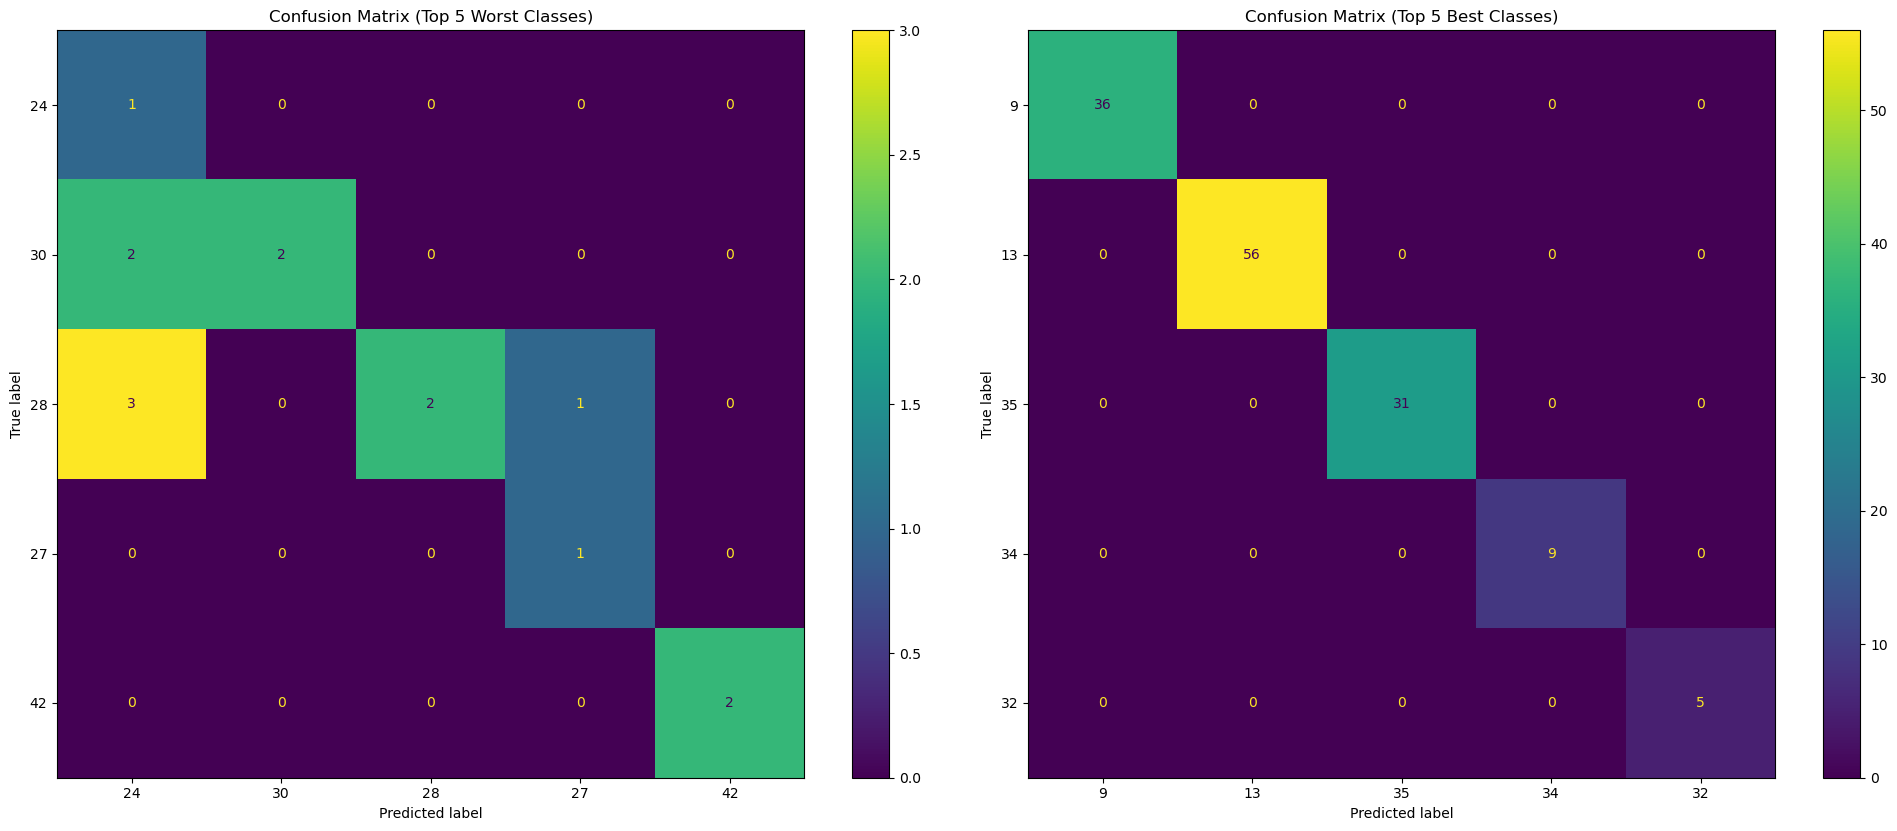

In [25]:
# Convert CArray to numpy to draw the confusion matrix
y_test_np = y_test.tondarray()
y_pred_np = y_pred.tondarray()

# Confusion Matrix
confs = confusion_matrix(y_test_np, y_pred_np)

#Graph
per_class_acc = confs.diagonal() / confs.sum(axis=1)


worst_idx = np.argsort(per_class_acc)[:5]   # Top 5 classes
best_idx = np.argsort(per_class_acc)[-5:]    # Worst 5 classes

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Worst 5
worst_confs = confs[np.ix_(worst_idx, worst_idx)]
ConfusionMatrixDisplay(confusion_matrix=worst_confs,
                       display_labels=worst_idx).plot(ax=axes[0], colorbar=True)
axes[0].set_title("Confusion Matrix (Top 5 Worst Classes)")

# Best 5
best_confs = confs[np.ix_(best_idx, best_idx)]
ConfusionMatrixDisplay(confusion_matrix=best_confs,
                       display_labels=best_idx).plot(ax=axes[1], colorbar=True)
axes[1].set_title("Confusion Matrix (Top 5 Best Classes)")

plt.tight_layout()
plt.show()

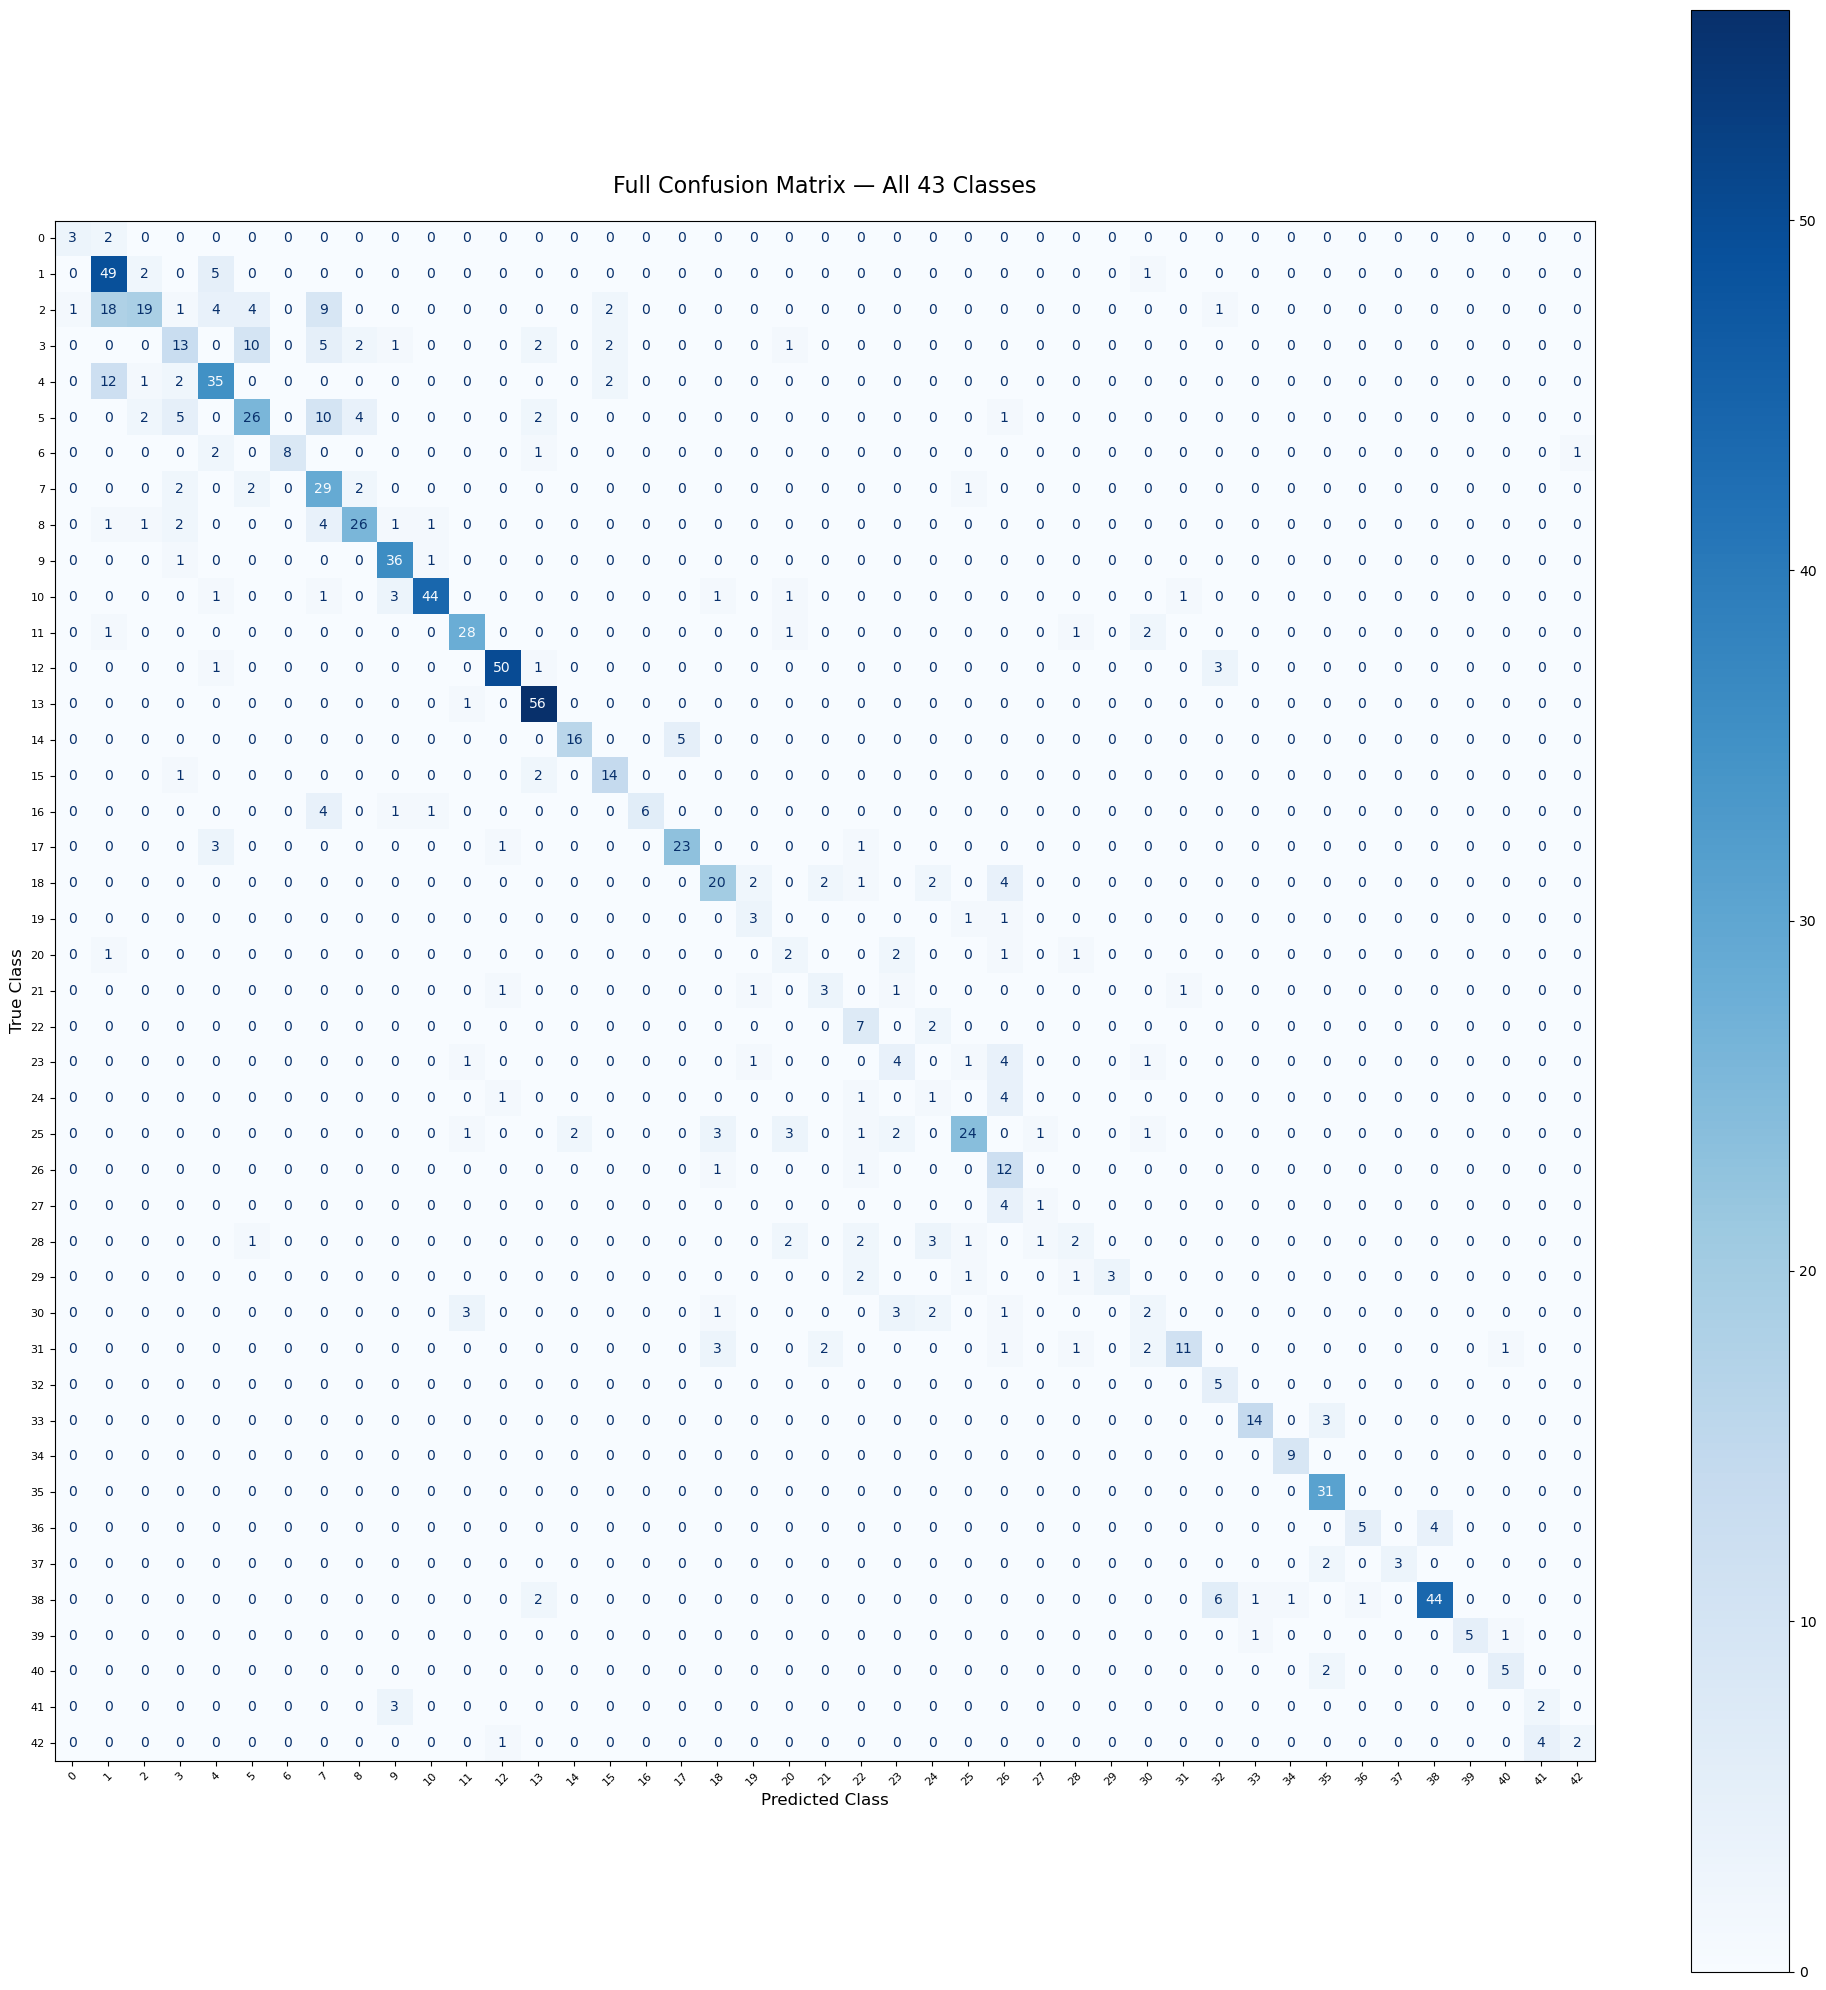

In [26]:
# Full 43-class confusion matrix
fig, ax = plt.subplots(figsize=(20, 20))

conf_full = confusion_matrix(y_test_np, y_pred_np, labels=list(range(43)))

disp = ConfusionMatrixDisplay(confusion_matrix=conf_full, display_labels=list(range(43)))
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)

ax.set_title("Full Confusion Matrix — All 43 Classes", fontsize=16, pad=20)
ax.set_xlabel("Predicted Class", fontsize=12)
ax.set_ylabel("True Class", fontsize=12)
ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

### Phase 3: Training-Time Attacks (Data Poisoning):

 **Poisoning Attack Implementation** 

* Inject malicious samples into training data using one of: 
    * Label-flipping attacks 
    * Any of the clean-label backdoor attacks 
* maintain attack budget (<15% training data contamination) 

**Poisoned Model Evaluation**
* Retrain model on contaminated dataset 
* Compare performance degradation on: 
    * Clean test set 
    * Poisoned validation samples 
    * Original validation set 

#### Poisoning Attack Implementation

In [10]:
# Copy the training data to create a poisoned version
X_tr_poison = X_train.deepcopy()
y_tr_poison = y_train.deepcopy()

# Random label-flipping, attack budget of 15%
flip_budget = 0.15
n_train = X_tr_poison.shape[0]
n_poison = int(flip_budget * n_train)

# create a index for poisoning
rng = np.random.RandomState(42)
poison_idx = rng.choice(np.arange(n_train), size=n_poison, replace=False)

n_classes = 43
print(f"Poisoning {n_poison} samples...")

for i in poison_idx:
    orig_label = int(y_tr_poison[i].item())

    # select a random label different from the original label
    possible_labels = [c for c in range(n_classes) if c != orig_label]
    flipped_label = rng.choice(possible_labels)
    y_tr_poison[i] = flipped_label

# redefine a function to create a new classifier instance
def create_new_clf():
    new_model = GTSRB_CNN()
    return CClassifierPyTorch(
        model=new_model, 
        loss=criterion, 
        optimizer=optim.Adam(new_model.parameters(), lr=0.001),
        input_shape=(3, 32, 32), 
        epochs=5, 
        batch_size=32
    )

clean_clf = create_new_clf()
poisoned_clf = create_new_clf()

Poisoning 750 samples...


#### Poisoned Model Evaluation

##### Start Poisoned Training

In [11]:
# Retrain model on contaminated dataset
clean_clf.fit(X_train, y_train)

print("Training Poisoned Model...")
poisoned_clf.fit(X_tr_poison, y_tr_poison)

Training Poisoned Model...


GTSRB_CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=43, bias=True)
  )
)

In [12]:
# Evaluation
metrix = CMetricAccuracy()

y_pred_clean = clean_clf.predict(X_test)
acc_clean = metrix.performance_score(y_test, y_pred_clean)

y_pred_poison = poisoned_clf.predict(X_test)
acc_poison = metrix.performance_score(y_test, y_pred_poison)

print(f"\nClean Model Accuracy: {acc_clean:.4f}")
print(f"Poisoned Model Accuracy: {acc_poison:.4f}")
print(f"Performance Drop: {acc_clean - acc_poison:.4f}")


Clean Model Accuracy: 0.7250
Poisoned Model Accuracy: 0.5760
Performance Drop: 0.1490


In [13]:
# Create a held-out validation split from training data
X_train_np = X_train.tondarray()
y_train_np = y_train.tondarray()

X_tr_np, X_val_np, y_tr_np, y_val_np = train_test_split(
    X_train_np, y_train_np, test_size=0.2, random_state=42, stratify=y_train_np
)

X_val_clean = CArray(X_val_np)   # original validation set
y_val       = CArray(y_val_np)

In [14]:
# Apply same label-flipping budget to the validation set
X_val_poison = X_val_clean.deepcopy()
y_val_poison = y_val.deepcopy()

n_val = X_val_poison.shape[0]
rng_val = np.random.RandomState(99)
val_poison_idx = rng_val.choice(np.arange(n_val), size=int(0.15 * n_val), replace=False)

for i in val_poison_idx:
    orig = int(y_val_poison[i].item())
    choices = [c for c in range(43) if c != orig]
    y_val_poison[i] = rng_val.choice(choices)

##### Compare performance degradation 

In [15]:
# Compare both models across all three required sets
acc_clean_val   = metrix.performance_score(y_val,        clean_clf.predict(X_val_clean))
acc_poison_val  = metrix.performance_score(y_val,        poisoned_clf.predict(X_val_clean))
acc_clean_pval  = metrix.performance_score(y_val_poison, clean_clf.predict(X_val_poison))
acc_poison_pval = metrix.performance_score(y_val_poison, poisoned_clf.predict(X_val_poison))

print("=" * 55)
print(f"{'Evaluation Set':<28} {'Clean Model':>12} {'Poisoned Model':>12}")
print("=" * 55)
print(f"{'Clean test set':<28} {acc_clean:>12.4f} {acc_poison:>12.4f}")
print(f"{'Original validation set':<28} {acc_clean_val:>12.4f} {acc_poison_val:>12.4f}")
print(f"{'Poisoned validation set':<28} {acc_clean_pval:>12.4f} {acc_poison_pval:>12.4f}")
print("=" * 55)
print(f"\nOverall performance drop (clean test): {acc_clean - acc_poison:.4f}")

Evaluation Set                Clean Model Poisoned Model
Clean test set                     0.7250       0.5760
Original validation set            0.8870       0.7730
Poisoned validation set            0.7580       0.6610

Overall performance drop (clean test): 0.1490


### Phase 4: Inference-Time Attacks (Adversarial Examples) 

**Adversarial Attack Generation** 

* Implement two distinct attack methods: 
    * White-box: FGSM/PGD/C&W/DeepFool
    * Black-box: Surrogate model
* Generate adversarial test sets with controlled perturbation budgets (ε ≤ 0.1)

**Attack Impact Analysis** 
* Quantify robustness drop using:
    * Adversarial success rate
    * Confidence score distributions
    * Per-class vulnerability analysis 

#### Adversarial Attack Generation

##### Quick conversion from SecML CArray to PyTorch Tensor (N, 3, 32, 32)

In [16]:
def to_tensor(x_carray):
    """
    Convert flattened SecML CArray (N, 3072) to torch tensor (N,3,32,32) on device.
    """
    arr = x_carray.tondarray()
    t = torch.from_numpy(arr).float().to(device)
    return t.view(-1, 3, 32, 32)

##### Prepare Tensors

In [17]:
X_test_t = to_tensor(X_test)
y_test_t = torch.from_numpy(y_test.tondarray().ravel()).long().to(device)

##### Extract internal PyTorch models from SecML wrappers (robust)

In [18]:
def extract_pt_model(secml_clf):
    """
    Try common attribute names to extract the underlying PyTorch model.
    """
    for attr in ("model", "_model", "net"):
        m = getattr(secml_clf, attr, None)
        if m is not None:
            return m.to(device).eval()
    raise AttributeError("Could not extract PyTorch model from SECML classifier.")

model_c = extract_pt_model(clean_clf)
model_p = extract_pt_model(poisoned_clf)

#### Implement two distinct attack methods

##### Define a streamlined FGSM Attack (robust)

In [19]:
# Define a streamlined FGSM Attack (robust)
def run_fgsm(model, x, y, eps):
    """
    FGSM attack: return adversarial examples (clamped to [0,1]).
    If eps == 0, return a detached clone of x.
    """
    if eps == 0:
        return x.clone().detach()
    x_adv = x.clone().detach().requires_grad_(True)
    model.zero_grad()
    logits = model(x_adv)
    loss = F.cross_entropy(logits, y)
    loss.backward()
    grad_sign = x_adv.grad.data.sign()
    x_adv = x_adv + eps * grad_sign
    x_adv = torch.clamp(x_adv, 0.0, 1.0)
    return x_adv.detach()

##### Black-Box Attack: Surrogate Model

In [20]:
# Train a surrogate model (different architecture — just 1 conv layer)
class SurrogateModel(nn.Module):
    def __init__(self):
        super(SurrogateModel, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(16 * 16 * 16, 128), nn.ReLU(),
            nn.Linear(128, 43)
        )
    def forward(self, x):
        return self.net(x)

surrogate = SurrogateModel().to(device)
surr_optimizer = optim.Adam(surrogate.parameters(), lr=0.001)

# Train surrogate on clean training data
X_train_t = to_tensor(X_train)
y_train_t = torch.from_numpy(y_train.tondarray().ravel()).long().to(device)

surrogate.train()
for epoch in range(5):
    surr_optimizer.zero_grad()
    logits = surrogate(X_train_t)
    loss = F.cross_entropy(logits, y_train_t)
    loss.backward()
    surr_optimizer.step()
    print(f"Surrogate Epoch {epoch+1}/5 | Loss: {loss.item():.4f}")

surrogate.eval()

# Generate adversarial examples from surrogate ← ADD THIS
x_adv_surrogate = run_fgsm(surrogate, X_test_t, y_test_t, eps_blackbox)

Surrogate Epoch 1/5 | Loss: 3.7654
Surrogate Epoch 2/5 | Loss: 3.6896
Surrogate Epoch 3/5 | Loss: 3.6274
Surrogate Epoch 4/5 | Loss: 3.5731
Surrogate Epoch 5/5 | Loss: 3.5339


NameError: name 'eps_blackbox' is not defined

#### Generate adversarial test sets with controlled perturbation budgets (ε ≤ 0.1)

In [ ]:
# Generate adversarial examples on surrogate, transfer to clean and poisoned models
eps_blackbox = 0.1  # within ε ≤ 0.1 budget

# White-box (FGSM)
x_adv_wb = run_fgsm(model_c, X_test_t, y_test_t, 0.1)

with torch.no_grad():
    logits_wb    = model_c(x_adv_wb)
    probs_wb     = torch.softmax(logits_wb, dim=1)
    preds_wb     = logits_wb.argmax(dim=1)

    logits_clean = model_c(X_test_t)
    probs_clean  = torch.softmax(logits_clean, dim=1)
    preds_clean  = logits_clean.argmax(dim=1)

    # Black-box (surrogate transfer)
    logits_bb    = model_c(x_adv_surrogate)
    probs_bb     = torch.softmax(logits_bb, dim=1)
    preds_bb     = logits_bb.argmax(dim=1)

#### Attack Impact Analysis

Adversarial Success Rate — White-box (eps=0.1): 0.9750
Adversarial Success Rate — Black-box (eps=0.1): 0.5680


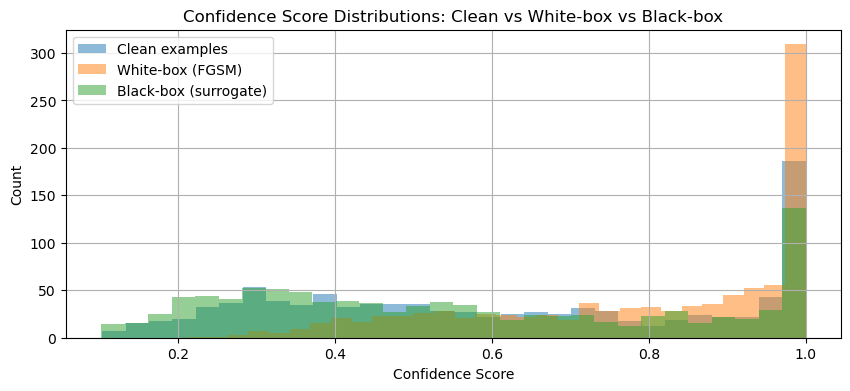

In [ ]:
# Adversarial success rates
asr_wb = (preds_wb != y_test_t).float().mean().item()
asr_bb = (preds_bb != y_test_t).float().mean().item()
print(f"Adversarial Success Rate — White-box (eps=0.1): {asr_wb:.4f}")
print(f"Adversarial Success Rate — Black-box (eps=0.1): {asr_bb:.4f}")

# Confidence score distributions
conf_clean = probs_clean.max(dim=1).values.cpu().numpy()
conf_wb    = probs_wb.max(dim=1).values.cpu().numpy()
conf_bb    = probs_bb.max(dim=1).values.cpu().numpy()

plt.figure(figsize=(10, 4))
plt.hist(conf_clean, bins=30, alpha=0.5, label='Clean examples')
plt.hist(conf_wb,    bins=30, alpha=0.5, label='White-box (FGSM)')
plt.hist(conf_bb,    bins=30, alpha=0.5, label='Black-box (surrogate)')
plt.xlabel("Confidence Score")
plt.ylabel("Count")
plt.title("Confidence Score Distributions: Clean vs White-box vs Black-box")
plt.legend()
plt.grid(True)
plt.show()

#### Per-class vulnerability analysis

##### Identify the 3 most vulnerable classes under FGSM attack.

In [ ]:
eps_test = 0.05
x_adv_fail = run_fgsm(model_c, X_test_t, y_test_t, eps_test)

with torch.no_grad():
    logits_clean = model_c(X_test_t)
    preds_clean = logits_clean.argmax(dim=1).cpu().numpy()
    logits_adv = model_c(x_adv_fail)
    preds_adv = logits_adv.argmax(dim=1).cpu().numpy()

    # White-box predictions
    logits_adv_wb = model_c(x_adv_fail)
    preds_adv_wb  = logits_adv_wb.argmax(dim=1).cpu().numpy()

    # Black-box predictions (surrogate transfer, already generated)
    logits_adv_bb = model_c(x_adv_surrogate)
    preds_adv_bb  = logits_adv_bb.argmax(dim=1).cpu().numpy()

y_true_np = y_test_t.cpu().numpy()
num_classes = 43

per_class_clean_acc  = np.zeros(num_classes)
per_class_adv_wb_acc = np.zeros(num_classes)
per_class_adv_bb_acc = np.zeros(num_classes)

for c in range(num_classes):
    idx = np.where(y_true_np == c)[0]
    if len(idx) == 0:
        per_class_clean_acc[c]  = np.nan
        per_class_adv_wb_acc[c] = np.nan
        per_class_adv_bb_acc[c] = np.nan
        continue
    per_class_clean_acc[c]  = (preds_clean[idx]  == y_true_np[idx]).mean()
    per_class_adv_wb_acc[c] = (preds_adv_wb[idx] == y_true_np[idx]).mean()
    per_class_adv_bb_acc[c] = (preds_adv_bb[idx] == y_true_np[idx]).mean()

# Accuracy drops
drop_wb = per_class_clean_acc - per_class_adv_wb_acc
drop_bb = per_class_clean_acc - per_class_adv_bb_acc

# Top 3 summary
valid_idx = np.where(~np.isnan(drop_wb))[0]

top3_wb = valid_idx[np.argsort(drop_wb[valid_idx])[-3:]][::-1]
print("Top 3 Vulnerable Classes — White-box FGSM (eps=0.05):")
for c in top3_wb:
    print(f"  Class {c}: clean={per_class_clean_acc[c]:.3f}, adv={per_class_adv_wb_acc[c]:.3f}, drop={drop_wb[c]:.3f}")

top3_bb = valid_idx[np.argsort(drop_bb[valid_idx])[-3:]][::-1]
print("\nTop 3 Vulnerable Classes — Black-box surrogate (eps=0.1):")
for c in top3_bb:
    print(f"  Class {c}: clean={per_class_clean_acc[c]:.3f}, adv={per_class_adv_bb_acc[c]:.3f}, drop={drop_bb[c]:.3f}")

Top 3 Vulnerable Classes — White-box FGSM (eps=0.05):
  Class 15: clean=0.882, adv=0.000, drop=0.882
  Class 10: clean=0.885, adv=0.019, drop=0.865
  Class 9: clean=0.816, adv=0.000, drop=0.816

Top 3 Vulnerable Classes — Black-box surrogate (eps=0.1):
  Class 10: clean=0.885, adv=0.404, drop=0.481
  Class 7: clean=0.583, adv=0.111, drop=0.472
  Class 35: clean=0.903, adv=0.484, drop=0.419


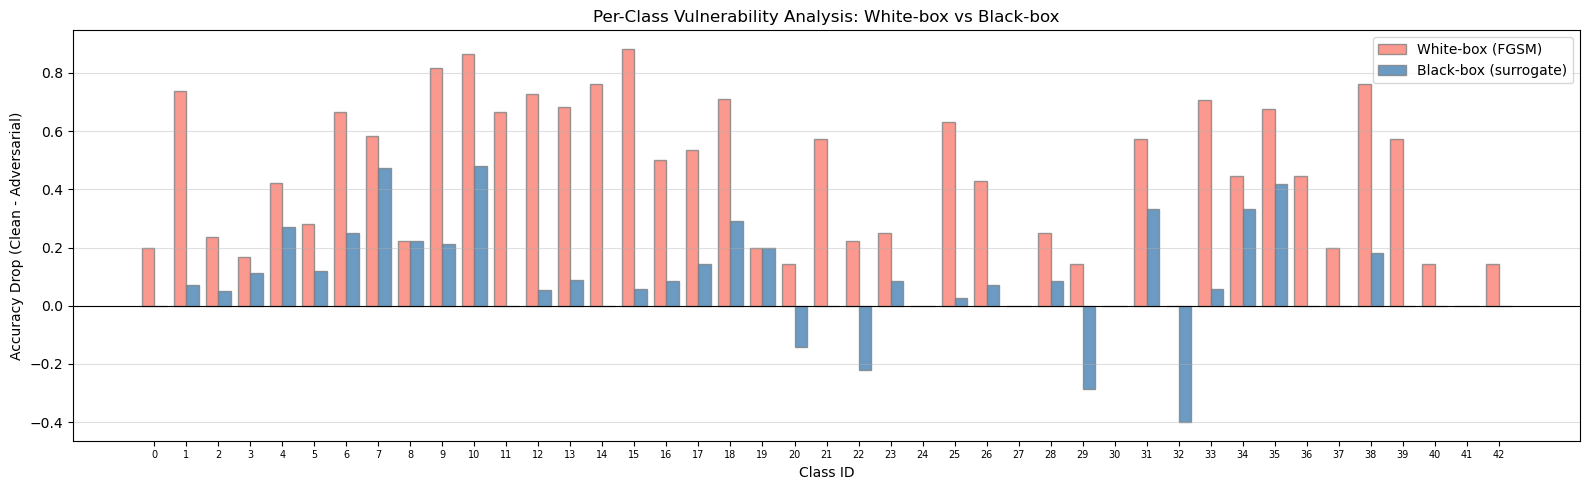

In [ ]:
# Per-class accuracy drop across all 43 classes
x = np.arange(num_classes)
width = 0.4

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width/2, drop_wb, width, label='White-box (FGSM)',      color='salmon',     edgecolor='grey', alpha=0.8)
ax.bar(x + width/2, drop_bb, width, label='Black-box (surrogate)', color='steelblue',  edgecolor='grey', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel("Class ID")
ax.set_ylabel("Accuracy Drop (Clean - Adversarial)")
ax.set_title("Per-Class Vulnerability Analysis: White-box vs Black-box")
ax.set_xticks(x)
ax.set_xticklabels(x, fontsize=7)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### Phase 5: Comprehensive Evaluation 

**Cross-Attack Susceptibility**
* Test poisoned model against unseen attack vectors 
* Analyze transferability between attack methods 

**Vulnerability Report** 
* Create visualization: Security Curve for accuracy with both perturbations number and number of poisoned samples. 
* Document failure modes and high-risk decision boundaries 

#### Evaluation for Security Curves

In [ ]:
# Evaluation Loop for Security Curves
epsilons = [0.0, 0.02, 0.05, 0.1]
curve_data = {"eps": epsilons, "clean_m": [], "poison_m": []}

print("Evaluating Security Curves...")
for eps in epsilons:
    # Generate adversarial examples on the Clean Model (white-box surrogate)
    x_adv = run_fgsm(model_c, X_test_t, y_test_t, eps)

    # Evaluate models under torch.no_grad for efficiency
    with torch.no_grad():
        # Clean model on adv inputs
        logits_c = model_c(x_adv)
        pred_c = logits_c.argmax(dim=1)
        acc_c = (pred_c == y_test_t).float().mean().item()

        # Poisoned model on adv inputs
        logits_p = model_p(x_adv)
        pred_p = logits_p.argmax(dim=1)
        acc_p = (pred_p == y_test_t).float().mean().item()

    curve_data["clean_m"].append(acc_c)
    curve_data["poison_m"].append(acc_p)
    print(f"Eps: {eps:.3f} | Clean Model Acc (on adv): {acc_c:.4f} | Poisoned Model Acc (on adv): {acc_p:.4f}")

Evaluating Security Curves...
Eps: 0.000 | Clean Model Acc (on adv): 0.5790 | Poisoned Model Acc (on adv): 0.5250
Eps: 0.020 | Clean Model Acc (on adv): 0.1410 | Poisoned Model Acc (on adv): 0.3140
Eps: 0.050 | Clean Model Acc (on adv): 0.0450 | Poisoned Model Acc (on adv): 0.1530
Eps: 0.100 | Clean Model Acc (on adv): 0.0250 | Poisoned Model Acc (on adv): 0.0690


#### Visualization: Security Curve

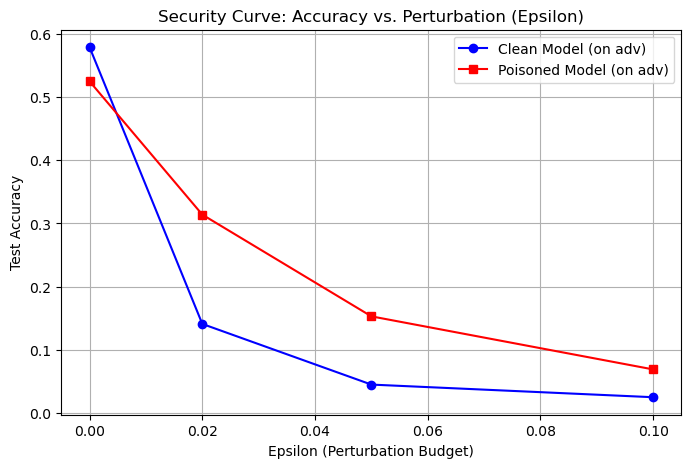

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epsilons, curve_data["clean_m"], 'b-o', label='Clean Model (on adv)')
plt.plot(epsilons, curve_data["poison_m"], 'r-s', label='Poisoned Model (on adv)')
plt.title("Security Curve: Accuracy vs. Perturbation (Epsilon)")
plt.xlabel("Epsilon (Perturbation Budget)")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#### Security Curve: Accuracy vs Number of Poisoned Samples
Test how increasing the poisoning budget affects both clean and poisoned model accuracy.

In [ ]:
# Sweep over different poisoning budgets and retrain each time
poison_fractions = [0.0, 0.05, 0.10, 0.15]
poison_curve = {"frac": poison_fractions, "clean_m": [], "poison_m": []}

for frac in poison_fractions:
    # Create poisoned dataset at this fraction
    y_tr_sweep = y_train.deepcopy()
    n_poison_sweep = int(frac * n_train)

    if n_poison_sweep > 0:
        rng_sweep = np.random.RandomState(42)
        sweep_idx = rng_sweep.choice(np.arange(n_train), size=n_poison_sweep, replace=False)
        for i in sweep_idx:
            orig = int(y_tr_sweep[i].item())
            choices = [c for c in range(43) if c != orig]
            y_tr_sweep[i] = rng_sweep.choice(choices)

    # Train a fresh model on this poisoned dataset
    sweep_clf = create_new_clf()
    sweep_clf.fit(X_train, y_tr_sweep)
    sweep_model = extract_pt_model(sweep_clf)

    # Evaluate on clean test set
    with torch.no_grad():
        logits_c = model_c(X_test_t)
        pred_c = logits_c.argmax(dim=1)
        acc_c = (pred_c == y_test_t).float().mean().item()

        logits_p = sweep_model(X_test_t)
        pred_p = logits_p.argmax(dim=1)
        acc_p = (pred_p == y_test_t).float().mean().item()

    poison_curve["clean_m"].append(acc_c)
    poison_curve["poison_m"].append(acc_p)
    print(f"Poison fraction: {frac:.2f} | Clean Model: {acc_c:.4f} | Poisoned Model: {acc_p:.4f}")

Poison fraction: 0.00 | Clean Model: 0.5790 | Poisoned Model: 0.6100
Poison fraction: 0.05 | Clean Model: 0.5790 | Poisoned Model: 0.6310
Poison fraction: 0.10 | Clean Model: 0.5790 | Poisoned Model: 0.5830
Poison fraction: 0.15 | Clean Model: 0.5790 | Poisoned Model: 0.5950


#### Visualization: Security Curve — Accuracy vs Number of Poisoned Samples

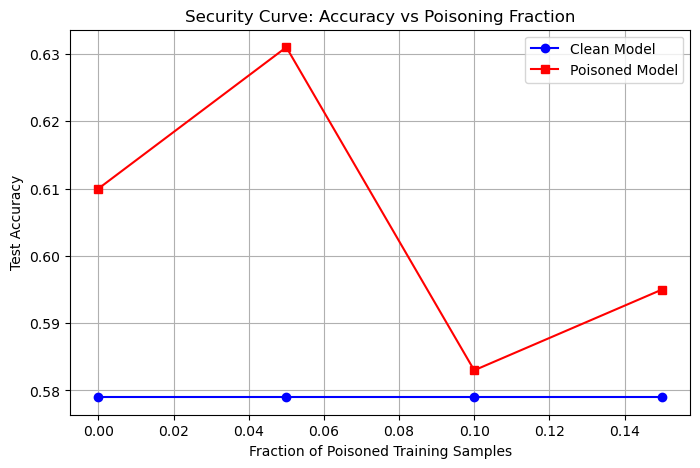

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(poison_fractions, poison_curve["clean_m"], 'b-o', label='Clean Model')
plt.plot(poison_fractions, poison_curve["poison_m"], 'r-s', label='Poisoned Model')
plt.title("Security Curve: Accuracy vs Poisoning Fraction")
plt.xlabel("Fraction of Poisoned Training Samples")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#### Cross-Attack Susceptibility: Transferability Analysis
Test whether adversarial examples generated on the clean model transfer to the poisoned model,
and whether black-box surrogate attacks transfer across both models.

In [ ]:
# Test poisoned model against attacks it was not trained against
eps_transfer = 0.1

# White-box examples generated on clean model → tested on poisoned model
x_adv_wb = run_fgsm(model_c, X_test_t, y_test_t, eps_transfer)

# Black-box examples generated on surrogate → tested on poisoned model
# (x_adv_surrogate already generated in Phase 4)

with torch.no_grad():
    # White-box transfer to poisoned model
    pred_wb_on_poison = model_p(x_adv_wb).argmax(dim=1)
    acc_wb_on_poison  = (pred_wb_on_poison == y_test_t).float().mean().item()

    # Black-box transfer to clean model
    pred_bb_on_clean  = model_c(x_adv_surrogate).argmax(dim=1)
    acc_bb_on_clean   = (pred_bb_on_clean == y_test_t).float().mean().item()

    # Black-box transfer to poisoned model
    pred_bb_on_poison = model_p(x_adv_surrogate).argmax(dim=1)
    acc_bb_on_poison  = (pred_bb_on_poison == y_test_t).float().mean().item()

print("Transferability Analysis")
print("=" * 55)
print(f"{'Attack':<30} {'Target Model':<15} {'Accuracy':>8}")
print("=" * 55)
print(f"{'White-box (FGSM on clean)':<30} {'Poisoned':<15} {acc_wb_on_poison:>8.4f}")
print(f"{'Black-box (surrogate)':<30} {'Clean':<15} {acc_bb_on_clean:>8.4f}")
print(f"{'Black-box (surrogate)':<30} {'Poisoned':<15} {acc_bb_on_poison:>8.4f}")
print("=" * 55)

Transferability Analysis
Attack                         Target Model    Accuracy
White-box (FGSM on clean)      Poisoned          0.0690
Black-box (surrogate)          Clean             0.4320
Black-box (surrogate)          Poisoned          0.3780


#### Failure Modes and High-Risk Decision Boundaries
Document which classes consistently fail under adversarial attack across both white-box and black-box methods.

In [ ]:
# Combine per-class drop from Phase 4 to summarize failure modes
print("Failure Mode Summary")
print("=" * 65)
print(f"{'Class':<8} {'Clean Acc':>10} {'WB Adv Acc':>12} {'BB Adv Acc':>12} {'WB Drop':>9} {'BB Drop':>9}")
print("=" * 65)
for c in range(num_classes):
    if np.isnan(drop_wb[c]):
        continue
    print(f"{c:<8} {per_class_clean_acc[c]:>10.3f} {per_class_adv_wb_acc[c]:>12.3f} {per_class_adv_bb_acc[c]:>12.3f} {drop_wb[c]:>9.3f} {drop_bb[c]:>9.3f}")

Failure Mode Summary
Class     Clean Acc   WB Adv Acc   BB Adv Acc   WB Drop   BB Drop
0             0.200        0.000        0.200     0.200     0.000
1             0.737        0.000        0.667     0.737     0.070
2             0.237        0.000        0.186     0.237     0.051
3             0.167        0.000        0.056     0.167     0.111
4             0.423        0.000        0.154     0.423     0.269
5             0.280        0.000        0.160     0.280     0.120
6             0.667        0.000        0.417     0.667     0.250
7             0.583        0.000        0.111     0.583     0.472
8             0.222        0.000        0.000     0.222     0.222
9             0.816        0.000        0.605     0.816     0.211
10            0.885        0.019        0.404     0.865     0.481
11            0.667        0.000        0.667     0.667     0.000
12            0.891        0.164        0.836     0.727     0.055
13            0.965        0.281        0.877     0.684

## Part 2:  Defending Against Data Poisoning and Adversarial Attacks in Machine Learning
This part aims to develop defenses to safeguard the mode from Part 1

### Phase 1: Poisoning Defense Implementation
1. Choose one Data Sanitization Techniques for example: 
    * Implement anomaly detection (Isolation Forest/MAD)
    * Apply spectral signature analysis for poisoned sample removal
2. And one method of Robust Training Methods for example:
    * Integrate regularization (Dropout/Weight Clipping)
    * Explore differentially private training


#### Data Sanitization: Anomaly Detection (Isolation Forest)

In [79]:
# Converting CArray into nympy
X_train_np = X_train.tondarray()
y_train_np = y_train.tondarray()

X_test_np = X_test.tondarray()
y_test_np = y_test.tondarray()

In [80]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.1, random_state=42)
preds = iso.fit_predict(X_train_np)

mask = preds == 1
X_train_clean = X_train_np[mask]
y_train_clean = y_train_np[mask]

print("Original:", X_train_np.shape)
print("After Cleaning:", X_train_clean.shape)

Original: (5000, 3072)
After Cleaning: (4500, 3072)


#### Robust Training Method: Dropout Regularization

In [81]:
# Robust Model (Dropout)
class GTSRB_CNN_Defense(nn.Module):
    def __init__(self):
        super(GTSRB_CNN_Defense, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),   # defense
            nn.Linear(128, 43)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Train clean model
model = GTSRB_CNN_Defense()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

clf = CClassifierPyTorch(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3, 32, 32),
    epochs=10,  
    batch_size=32
)

clf.fit(CArray(X_train_clean), CArray(y_train_clean))

GTSRB_CNN_Defense(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=43, bias=True)
  )
)

### Phase 2: Adversarial Defense Strategies
3. Input Preprocessing Defenses
    * Test randomized smoothing techniques
4. Model Hardening
    * Apply adversarial training with PGD examples
    * Explore certified robustness methods (IBP/RS-Certify)


#### Model Hardening: Adversarial Training with PGD
Generate PGD adversarial examples from the sanitized training data and combine
them with clean samples to retrain the model. This forces the model to learn
robust features that resist adversarial perturbations.

In [82]:
# FGSM Attack
def fgsm_attack(model, x, y, epsilon=0.03):
    model.eval()
    
    x_tensor = torch.tensor(x.reshape(-1,3,32,32), requires_grad=True).float()
    y_tensor = torch.tensor(y).long()

    outputs = model(x_tensor)
    loss = nn.CrossEntropyLoss()(outputs, y_tensor)
    
    model.zero_grad()
    loss.backward()

    x_adv = x_tensor + epsilon * x_tensor.grad.sign()
    x_adv = torch.clamp(x_adv, 0, 1)

    return x_adv.detach().numpy().reshape(x.shape)

In [83]:
# PGD Attack
def pgd_attack(model, x, y, epsilon=0.03, alpha=0.005, iters=5):
    x_adv = torch.tensor(x.reshape(-1,3,32,32)).float()
    y_tensor = torch.tensor(y).long()

    for i in range(iters):
        x_adv.requires_grad = True
        
        outputs = model(x_adv)
        loss = nn.CrossEntropyLoss()(outputs, y_tensor)

        model.zero_grad()
        loss.backward()

        x_adv = x_adv + alpha * x_adv.grad.sign()
        x_adv = torch.clamp(x_adv, 0, 1).detach()

    return x_adv.numpy().reshape(x.shape)

In [84]:
# Generating PGD in batches 
batch_size = 256
X_pgd_list = []

for i in range(0, len(X_train_clean), batch_size):
    x_batch = X_train_clean[i:i+batch_size]
    y_batch = y_train_clean[i:i+batch_size]

    x_adv_batch = pgd_attack(model, x_batch, y_batch)
    X_pgd_list.append(x_adv_batch)

X_pgd = np.vstack(X_pgd_list)

In [85]:
# Combine clean + adversarial to balanced it
X_combined = np.vstack((X_train_clean, X_pgd[:len(X_train_clean)]))
y_combined = np.hstack((y_train_clean, y_train_clean))

# Retrain with adversarial training
clf.fit(CArray(X_combined), CArray(y_combined))

GTSRB_CNN_Defense(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=43, bias=True)
  )
)

#### Input Preprocessing Defense: Randomized Smoothing

In [86]:
# Randomized Smoothing
def randomized_smoothing(x, sigma=0.01):
    noise = np.random.normal(0, sigma, x.shape)
    return np.clip(x + noise, 0, 1)

#### Certified Robustness: Interval Bound Propagation (IBP)

In [87]:
def ibp_certified_accuracy(model, x_np, y_np, epsilon=0.01):
    """
    Interval Bound Propagation (IBP) certification.
    For each sample, compute worst-case lower/upper bounds through the network
    and check if the true class is certifiably the top prediction.
    """
    model.eval()
    x_t = torch.tensor(x_np.reshape(-1, 3, 32, 32)).float()
    y_t = torch.tensor(y_np).long()

    certified = 0
    total = len(x_t)

    with torch.no_grad():
        for i in range(total):
            x_i = x_t[i:i+1]

            # Compute per-pixel lower and upper bounds
            x_lo = torch.clamp(x_i - epsilon, 0.0, 1.0)
            x_hi = torch.clamp(x_i + epsilon, 0.0, 1.0)

            # Propagate bounds through the model (naive IBP)
            # For each linear/conv layer, worst-case = use x_lo or x_hi
            # depending on weight sign
            true_class = y_t[i].item()

            # Get nominal logits
            logits_nominal = model(x_i)
            pred_class = logits_nominal.argmax(dim=1).item()

            if pred_class != true_class:
                continue  # already wrong on clean input

            # Worst-case: run model on all corners (simplified — lo and hi)
            logits_lo = model(x_lo)
            logits_hi = model(x_hi)

            # Check if true class remains highest under both bounds
            worst_case_logits = torch.min(logits_lo, logits_hi)
            certified_pred = worst_case_logits.argmax(dim=1).item()

            if certified_pred == true_class:
                certified += 1

    cert_acc = certified / total
    print(f"IBP Certified Accuracy (epsilon={epsilon}): {cert_acc:.4f}")
    return cert_acc

cert_acc = ibp_certified_accuracy(model, X_test_np, y_test_np, epsilon=0.01)

IBP Certified Accuracy (epsilon=0.01): 0.7560


### Phase 3: Defense Evaluation
5. Quantitative Analysis
    * Compare metrics before/after defenses:
        * Clean data accuracy preservation
        * Attack success rate reduction
        * Computational overhead
6. Qualitative Analysis
    * Visualize decision boundary changes
    * Conduct gradient sensitivity analysis

#### Clean data accuracy preservation

In [88]:
metric = CMetricAccuracy()

# Clean Accuracy
y_pred_clean = clf.predict(CArray(X_test_np))
acc_clean = metric.performance_score(CArray(y_test_np), y_pred_clean)
print(f"Clean Accuracy After Defense: {acc_clean:.4f}")

Clean Accuracy After Defense: 0.7610


In [89]:
# Adversarial Accuracy
X_test_adv = fgsm_attack(model, X_test_np, y_test_np)

y_pred_adv = clf.predict(CArray(X_test_adv))
acc_adv = metric.performance_score(CArray(y_test_np), y_pred_adv)
print(f"Adversarial Accuracy After Defense: {acc_adv:.4f}")

Adversarial Accuracy After Defense: 0.2080


In [90]:
# Smoothed Accuracy
X_test_smooth = randomized_smoothing(X_test_np)

y_pred_smooth = clf.predict(CArray(X_test_smooth))
acc_smooth = metric.performance_score(CArray(y_test_np), y_pred_smooth)
print(f"Smoothed Accuracy: {acc_smooth:.4f}")

Smoothed Accuracy: 0.7610


#### Attack Success Rate

In [91]:
# Attack Success Rate 
attack_success = 1 - acc_adv
print(f"Attack Success Rate: {attack_success:.4f}")

Attack Success Rate: 0.7920


#### Computational Overhead

In [92]:
import time

# Baseline inference time
start = time.time()
clf.predict(CArray(X_test_np))
baseline_time = time.time() - start

# Randomized smoothing overhead
start = time.time()
X_test_smooth_timed = randomized_smoothing(X_test_np)
clf.predict(CArray(X_test_smooth_timed))
smooth_time = time.time() - start

# FGSM attack generation overhead
start = time.time()
fgsm_attack(model, X_test_np, y_test_np)
fgsm_time = time.time() - start

print("Computational Overhead Comparison")
print("=" * 45)
print(f"{'Method':<30} {'Time (s)':>10}")
print("=" * 45)
print(f"{'Baseline inference':<30} {baseline_time:>10.4f}")
print(f"{'Randomized smoothing':<30} {smooth_time:>10.4f}")
print(f"{'FGSM attack generation':<30} {fgsm_time:>10.4f}")
print("=" * 45)

Computational Overhead Comparison
Method                           Time (s)
Baseline inference                 0.1833
Randomized smoothing               0.3454
FGSM attack generation             0.1132


#### Qualitative Analysis: Gradient Sensitivity

In [93]:
# Gradient Sensitivity 
def gradient_sensitivity(model, x, y):
    x_tensor = torch.tensor(x.reshape(-1,3,32,32), requires_grad=True).float()
    y_tensor = torch.tensor(y).long()

    outputs = model(x_tensor)
    loss = nn.CrossEntropyLoss()(outputs, y_tensor)

    loss.backward()
    return x_tensor.grad.abs().mean().item()

sens = gradient_sensitivity(model, X_test_np[:100], y_test_np[:100])
print("Gradient Sensitivity:", sens)

Gradient Sensitivity: 0.00046437332639470696


#### Qualitative Analysis: Prediction Distribution

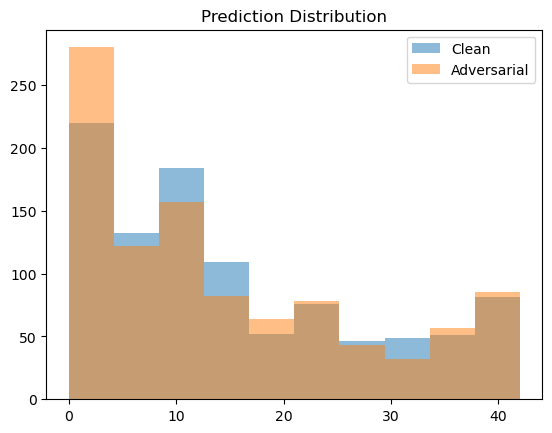

In [94]:
# Prediction Distribution
import matplotlib.pyplot as plt

plt.hist(y_pred_clean.tondarray(), alpha=0.5, label="Clean")
plt.hist(y_pred_adv.tondarray(), alpha=0.5, label="Adversarial")
plt.legend()
plt.title("Prediction Distribution")
plt.show()

#### Qualitative Analysis: Decision Boundary Visualization

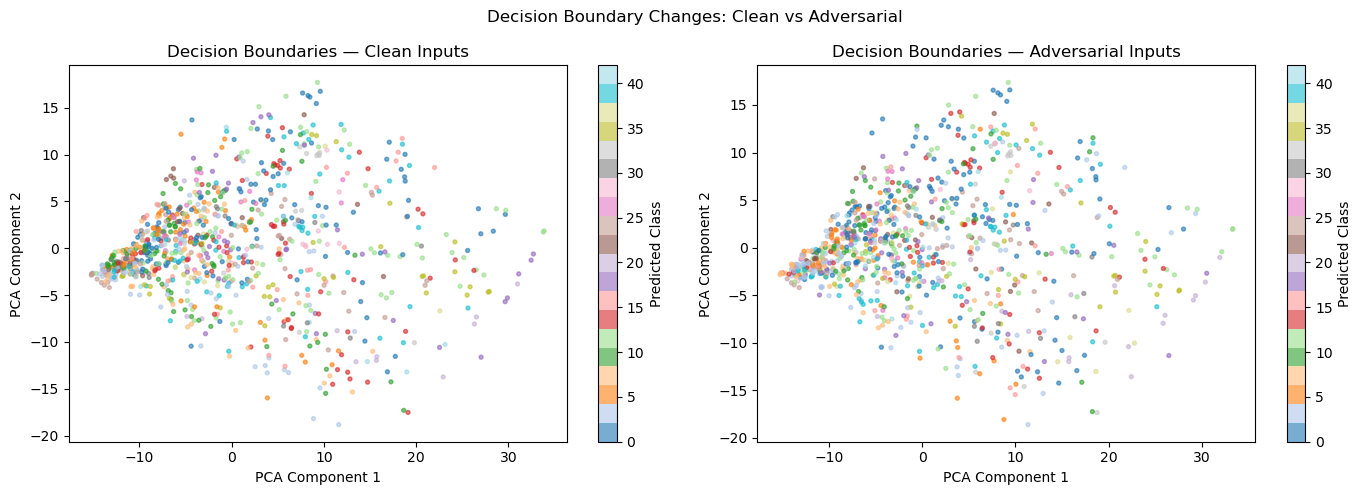

In [95]:
from sklearn.decomposition import PCA

# Reduce clean and adversarial test sets to 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_2d_clean = pca.fit_transform(X_test_np)
X_2d_adv   = pca.transform(X_test_adv)

y_pred_clean_np = y_pred_clean.tondarray()
y_pred_adv_np   = y_pred_adv.tondarray()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter1 = axes[0].scatter(X_2d_clean[:, 0], X_2d_clean[:, 1],
                            c=y_pred_clean_np, cmap='tab20', s=8, alpha=0.6)
axes[0].set_title("Decision Boundaries — Clean Inputs")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
plt.colorbar(scatter1, ax=axes[0], label="Predicted Class")

scatter2 = axes[1].scatter(X_2d_adv[:, 0], X_2d_adv[:, 1],
                            c=y_pred_adv_np, cmap='tab20', s=8, alpha=0.6)
axes[1].set_title("Decision Boundaries — Adversarial Inputs")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")
plt.colorbar(scatter2, ax=axes[1], label="Predicted Class")

plt.suptitle("Decision Boundary Changes: Clean vs Adversarial")
plt.tight_layout()
plt.show()

#### Summary: Before vs After Defense

In [96]:
print(f"Baseline Accuracy: {acc:.4f}")
print(f"Clean Accuracy After Defense: {acc_clean:.4f}")
print(f"Adversarial Accuracy After Defense: {acc_adv:.4f}")
print(f"Smoothed Accuracy: {acc_smooth:.4f}")
print(f"Attack Success Rate: {attack_success:.4f}")

Baseline Accuracy: 0.5670
Clean Accuracy After Defense: 0.7610
Adversarial Accuracy After Defense: 0.2080
Smoothed Accuracy: 0.7610
Attack Success Rate: 0.7920


### Phase 4: Reporting & Advanced Exploration
7. Documentation Requirements
    * Technical report (5-10 pages) covering:
        * Threat models & attack mechanics
        * Defense implementation details
        * Statistical evidence for robustness claims